# Demo: Face localization and blurring

This notebook:
- Loads the trained model.
- Runs inference on a single image.
- Draws the predicted bounding box and blurs the face.

In [3]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from src.models import BackboneNN, ClassificationNN, RegressionNN

## Configuration

In [ ]:
# Paths
WEIGHTS_DIR = r"XXXX"
IMAGE_PATH = r"XXXX"  # change this to any image you want to test

# Model settings (must match your training config)
WIDTH_TARGET = 224
HEIGHT_TARGET = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Load model

In [17]:
# Initialize models
backbone = BackboneNN()
classification_head = ClassificationNN()
regression_head = RegressionNN()

# Load weights
backbone.load_state_dict(
    torch.load(os.path.join(WEIGHTS_DIR, "backbone.pth"), map_location=DEVICE)
)
classification_head.load_state_dict(
    torch.load(
        os.path.join(WEIGHTS_DIR, "classification_head.pth"), map_location=DEVICE
    )
)
regression_head.load_state_dict(
    torch.load(
        os.path.join(WEIGHTS_DIR, "regression_head.pth"), map_location=DEVICE
    )
)

backbone = backbone.to(DEVICE).eval()
classification_head = classification_head.to(DEVICE).eval()
regression_head = regression_head.to(DEVICE).eval()

## Helper functions

In [18]:
def preprocess_image(image_path, width=224, height=224):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((width, height), Image.LANCZOS)
    img_np = np.array(img_resized).astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0)
    return img_tensor, img


def decode_bbox(pred_norm, orig_w, orig_h):
    """
    pred_norm: [x1_norm, y1_norm, w_norm, h_norm] in [0, 1]
    returns: [x1, y1, x2, y2] in original image coordinates
    """
    x1_norm, y1_norm, w_norm, h_norm = pred_norm
    x1 = x1_norm * orig_w
    y1 = y1_norm * orig_h
    x2 = (x1_norm + w_norm) * orig_w
    y2 = (y1_norm + h_norm) * orig_h
    return int(x1), int(y1), int(x2), int(y2)


def blur_face(img, bbox, blur_ksize=(51, 51)):
    img_np = np.array(img)
    x1, y1, x2, y2 = bbox
    face = img_np[y1:y2, x1:x2]
    blurred = cv2.GaussianBlur(face, blur_ksize, 0)
    img_np[y1:y2, x1:x2] = blurred
    return Image.fromarray(img_np)


def draw_bbox(img, bbox, color=(255, 0, 0), width=3):
    img_np = np.array(img)
    x1, y1, x2, y2 = bbox
    cv2.rectangle(img_np, (x1, y1), (x2, y2), color, width)
    return Image.fromarray(img_np)

## Run inference

In [19]:
# Load and preprocess image
img_tensor, img_orig = preprocess_image(
    IMAGE_PATH, width=WIDTH_TARGET, height=HEIGHT_TARGET
)
img_tensor = img_tensor.to(DEVICE)

# Forward pass
with torch.no_grad():
    features = backbone(img_tensor)
    class_logits = classification_head(features)
    bbox_norm = regression_head(features)

# Predicted class
class_probs = torch.softmax(class_logits, dim=1)
pred_class_id = torch.argmax(class_probs, dim=1).item()
pred_conf = class_probs[0, pred_class_id].item()

class_names = ["human", "cat", "dog"]
pred_class_name = class_names[pred_class_id]

print(f"Predicted class: {pred_class_name} (confidence: {pred_conf:.3f})")

Predicted class: human (confidence: 0.989)


## Draw box and blur (if human)

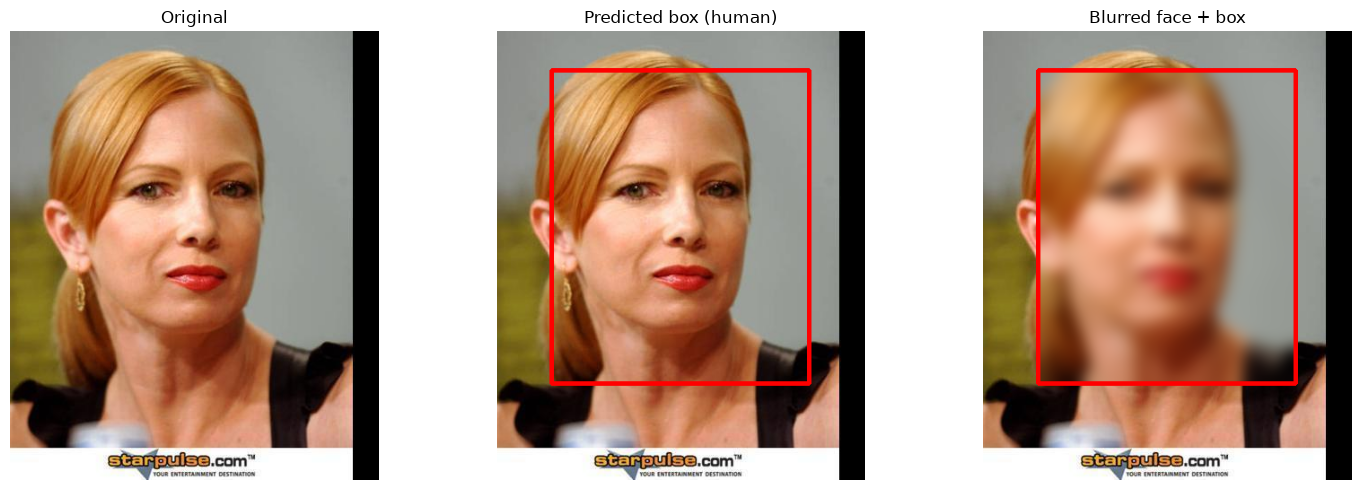

In [20]:
# Original image size
orig_w, orig_h = img_orig.size

if pred_class_name == "human":
    # Decode bounding box to original image coordinates
    bbox_norm = bbox_norm.cpu().numpy()[0]
    bbox = decode_bbox(bbox_norm, orig_w, orig_h)

    # Draw predicted box (red)
    img_with_box = draw_bbox(img_orig, bbox, color=(255, 0, 0), width=4)

    # Blur face
    img_blurred = blur_face(img_orig, bbox, blur_ksize=(51, 51))
    img_blurred_with_box = draw_bbox(img_blurred, bbox, color=(255, 0, 0), width=4)

    # Show results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_orig)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(img_with_box)
    axes[1].set_title(f"Predicted box ({pred_class_name})")
    axes[1].axis("off")

    axes[2].imshow(img_blurred_with_box)
    axes[2].set_title("Blurred face + box")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

else:
    # Just show original image with predicted class
    plt.figure(figsize=(6, 6))
    plt.imshow(img_orig)
    plt.title(f"Predicted: {pred_class_name} (confidence: {pred_conf:.3f})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()